In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text 
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.preprocessing import MultiLabelBinarizer
import re 
import seaborn as sns
#import nltk
#from nltk.corpus import stopwords
from transformers import AutoTokenizer, AutoModel
import torch


c:\Users\smahmood\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df_admits = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\admissions.csv.gz', compression='gzip')
df_pat = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\patients.csv.gz', compression='gzip')
df_icd_proc = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\d_icd_procedures.csv.gz', compression='gzip')
df_icd_diagnosis = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\d_icd_diagnoses.csv.gz', compression='gzip')
df_proc = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\procedures_icd.csv.gz', compression='gzip')
df_diagnosis = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\diagnoses_icd.csv.gz', compression='gzip')
df_transfers = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\transfers.csv.gz', compression='gzip')
df_medi = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\emar.csv.gz', compression='gzip')
#df_medi_details = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\emar_detail.csv.gz', compression='gzip')


In [2]:
df_admits = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\admissions.csv.gz', compression='gzip')
df_pat = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\patients.csv.gz', compression='gzip')
df_icd_proc = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\d_icd_procedures.csv.gz', compression='gzip')
df_icd_diagnosis = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\d_icd_diagnoses.csv.gz', compression='gzip')
df_proc = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\procedures_icd.csv.gz', compression='gzip')
df_diagnosis = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\diagnoses_icd.csv.gz', compression='gzip')
#df_transfers = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\transfers.csv.gz', compression='gzip')
df_medi = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\emar.csv.gz', compression='gzip')
#df_medi_details = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\emar_detail.csv.gz', compression='gzip')


In [3]:
#print(df_admits.head(10))
#print(df_diagnosis.head(10))
#print(df_icd_proc.head(10))
#print(df_icd_diagnosis.head(10))
df_pat.head(10)

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13
5,10000102,F,27,2136,2008 - 2010,NaN
6,10000108,M,25,2163,2014 - 2016,NaN
7,10000115,M,24,2154,2017 - 2019,NaN
8,10000117,F,48,2174,2008 - 2010,NaN
9,10000161,M,60,2163,2020 - 2022,NaN


In [35]:
# Data Checks

#df_admits.isna().any() # check which columns have NaN
df_admits.loc[:,df_admits.isna().any()]
#df_admits[df_admits['admission_location'] == '']
#pd.reset_option('display.max_rows')


,deathtime,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,edregtime,edouttime
0,NaN,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,2180-05-06 19:17:00,2180-05-06 23:30:00
1,NaN,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,2180-06-26 15:54:00,2180-06-26 21:31:00
2,NaN,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,2180-08-05 20:58:00,2180-08-06 01:44:00
3,NaN,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,2180-07-23 05:54:00,2180-07-23 14:00:00
4,NaN,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,2160-03-03 21:55:00,2160-03-04 06:26:00
...,...,...,...,...,...,...,...,...,...
546023,NaN,P13JMH,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,English,SINGLE,2149-01-08 09:11:00,2149-01-08 18:12:00
546024,NaN,P38XL8,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicaid,English,SINGLE,2147-07-17 17:18:00,2147-07-18 17:34:00
546025,2164-09-17 13:42:00,P33612,EMERGENCY ROOM,DIED,Private,English,WIDOWED,2164-09-10 11:09:00,2164-09-10 14:46:00
546026,NaN,P036NA,EMERGENCY ROOM,HOME,Private,English,WIDOWED,2164-07-24 21:16:00,2164-07-25 01:20:00


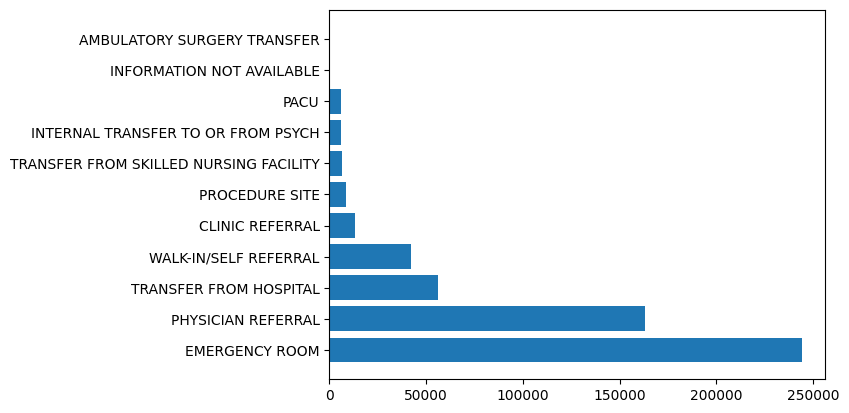

In [6]:
plt.barh(df_admits['admission_location'].value_counts().index,df_admits.admission_location.value_counts().values)
plt.show() # to check for missing values 

In [6]:
# Join diagnosis, admissions and procs
df_admit_icd = pd.merge(df_admits,df_diagnosis,how = 'left', on = 'hadm_id')
df_admit_diagnosis = pd.merge(df_admit_icd,df_icd_diagnosis,how = 'left', on = 'icd_code')
df_admit_diagnosis = pd.merge(df_admit_diagnosis,df_icd_proc,how = 'left', on = 'icd_code')
df_admit_diagnosis.drop(columns= ['subject_id_y'], inplace = True)
df_admit_diagnosis.rename(columns={'long_title_x': 'icd_diagnosis_name','long_title_y':'proc_name','subject_id_x':'subject_id'}, inplace=True)
df_admit_diagnosis = pd.merge(df_admit_diagnosis,df_pat[['subject_id', 'anchor_age','gender']],how = 'left', on = 'subject_id')

In [4]:
pd.set_option('display.max_columns', None)
df_icd_proc[df_icd_proc['icd_code']=='2764'].head(5)
#df_icd_diagnosis.head(5)

,icd_code,icd_version,long_title
72544,2764,9,Insertion of palatal implant


In [ ]:
# Next stage
# 1 - Group diagnosis and procedures using ICD code
# 2 - Enocode catgeorical features
# 3 - Assign appointment readimission instance flags

In [117]:
# 1. 
# 
# Check for how many diagnosis that exist - will need to group diagnosis first for easier encoding
#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', None)
pd.reset_option('display.max_rows')

#df_admit_diagnosis.proc_name.value_counts()

In [7]:
#pd.reset_option('display.max_rows')
# Replace all NaN with 'No Diagnosis'
df_admit_diagnosis['icd_diagnosis_name'] = df_admit_diagnosis['icd_diagnosis_name'].fillna('No Diagnosis')
df_admit_diagnosis['proc_name'] = df_admit_diagnosis['proc_name'].fillna('No Procedure')
df_admit_diagnosis['icd_code'] = df_admit_diagnosis['icd_code'].fillna('No ICD Code')
df_admit_diagnosis[df_admit_diagnosis['proc_name'].isna()]

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,hospital_expire_flag,seq_num,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name,anchor_age,gender


In [8]:
#diagnosis_counts = df_admit_diagnosis.icd_diagnosis_name.value_counts()
#df_admit_diagnosis['diagnosis_grouped'] = df_admit_diagnosis.icd_diagnosis_name.apply(lambda x: x if diagnosis_counts[x] >= 1000 else 'Rarer Diagnosis')
icd_counts = df_admit_diagnosis.icd_code.value_counts()
df_admit_diagnosis['icd_code_converted'] = df_admit_diagnosis.icd_code.apply(lambda x: str(x) if icd_counts[x] > 1000 else ('Other Code' if icd_counts[x] < 1000 else 'No ICD code'))

In [9]:
df_admit_diagnosis.drop(columns = ['icd_version_y','icd_version_x','edregtime','edouttime','deathtime','admit_provider_id','hospital_expire_flag',
                                          'seq_num','icd_code','language','icd_version'],inplace = True)

In [12]:
pd.set_option('display.max_rows', 10000)    
#pd.reset_option('display.max_rows')
#print(df_admit_diagnosis.diagnosis_grouped.value_counts().head(10000))
print(df_admit_diagnosis.icd_code_converted.value_counts().head(10000))

icd_code_converted
Other Code     1457032
4019            102368
E785             84570
I10              83775
2724             67293
Z87891           62806
K219             56157
53081            48628
25000            43077
F329             41876
I2510            41550
F419             38911
42731            37070
4280             36606
311              36349
41401            36083
N179             35884
Z20822           33113
V1582            31705
Z7901            30957
5849             29136
2449             28521
E039             28000
Z794             27642
E119             26266
3051             25879
2859             24395
F17210           24106
G4733            23933
40390            23831
V5861            22635
30000            22399
E669             22004
V270             21238
D649             21137
I4891            21022
J45909           20679
5990             20387
Z7902            19961
2720             19880
Y929             19830
49390            19703
V5867          

In [10]:
# Group first to reduce data size
df_admit_diagnosis = df_admit_diagnosis.groupby(['hadm_id', 'subject_id']).agg({  
     'admission_type':'first',
     'admission_location': 'first',
     'discharge_location':'first',
     'admittime':'first',
     'dischtime':'first',
     'insurance':'first',
     'marital_status': 'first',
     'race':'first',
     'anchor_age': 'first',
     'gender':'first',
     'icd_code_converted': lambda x: set(x),
     'icd_diagnosis_name': lambda x: set(x),
     'proc_name': lambda x: set(x),
     }).reset_index()
df_admit_diagnosis.head(5)  

,hadm_id,subject_id,admission_type,admission_location,discharge_location,admittime,dischtime,insurance,marital_status,race,anchor_age,gender,icd_code_converted,icd_diagnosis_name,proc_name
0,20000019,10467237,EW EMER.,EMERGENCY ROOM,HOME,2159-03-20 21:08:00,2159-03-23 16:54:00,Medicaid,SINGLE,HISPANIC/LATINO - GUATEMALAN,76,F,"{0389, 59080, 2761, 25000, 4019, 2859, 2724, 9...","{Unspecified essential hypertension, Asthma, u...",{Other diagnostic procedures on lymphatic stru...
1,20000024,16925328,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,2151-05-25 21:44:00,2151-05-26 18:36:00,Medicare,SINGLE,WHITE,84,F,"{K521, Other Code, Z9181, H548, M810, E538, I1...","{Toxic gastroenteritis and colitis, Adverse ef...",{No Procedure}
2,20000034,19430048,DIRECT OBSERVATION,PHYSICIAN REFERRAL,None,2174-05-22 19:13:00,2174-05-24 17:27:00,Medicare,SINGLE,BLACK/CARIBBEAN ISLAND,72,M,"{G4700, M4800, E871, N183, Z87891, K8689, Z851...","{Chronic kidney disease, stage 3 (moderate), I...",{Physical Rehabilitation and Diagnostic Audiol...
3,20000041,18910522,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,2143-09-03 07:15:00,2143-09-06 13:50:00,Private,SINGLE,WHITE,62,F,"{V1251, V8541, 71536, 27800, 25002, 4019, 2724...","{Unspecified essential hypertension, Personal ...",{Other diagnostic procedures on lymphatic stru...
4,20000045,13413708,OBSERVATION ADMIT,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,2138-05-21 16:25:00,2138-05-29 02:05:00,Private,DIVORCED,WHITE,51,F,"{D6481, B9620, C7951, D630, C787, A419, E8339,...",{Other intestinal obstruction unspecified as t...,{No Procedure}


In [11]:
# Assign admission ranks throughout time
# Readmission is within 30 days of discharge and next admission so insert flag

df_admit_diagnosis['admittime'] = pd.to_datetime(df_admit_diagnosis['admittime'])
df_admit_diagnosis['dischtime'] = pd.to_datetime(df_admit_diagnosis['dischtime'])

df_admit_diagnosis['admission_rank'] = df_admit_diagnosis.groupby('subject_id')['admittime'].rank(method='dense', ascending=True)
df_admit_diagnosis.sort_values(by = ['admission_rank'],ascending= True, inplace= True)
# Get next admission's out time for each patient
df_admit_diagnosis['last_dischtime'] = df_admit_diagnosis.groupby('subject_id')['dischtime'].shift(1)

# Calculate days until next visit
df_admit_diagnosis['days_from_last'] = (df_admit_diagnosis['admittime'] - df_admit_diagnosis['last_dischtime']).dt.days

# Create readmission flag (1 if last visit is within 30 days, else 0)
df_admit_diagnosis['readmission'] = df_admit_diagnosis['days_from_last'].apply(lambda x: 1 if pd.notnull(x) and x <= 30 and x >= 0 else 0)

#df_admit_diagnosis[df_admit_diagnosis['subject_id'] == 10000032]

In [12]:
# label encode the text columns
df_admit_diagnosis_encoded = df_admit_diagnosis.drop(columns= ['admittime','dischtime','last_dischtime','days_from_last', 'admission_rank']) # drop irrelevant cols

cols_to_encode = ['admission_type','admission_location','discharge_location','insurance','race','gender','marital_status']
label_encoder = preprocessing.LabelEncoder()
for col in cols_to_encode:
    df_admit_diagnosis_encoded[col] = label_encoder.fit_transform(df_admit_diagnosis[col])
df_admit_diagnosis_encoded[df_admit_diagnosis_encoded['subject_id'] == 10000032]


,hadm_id,subject_id,admission_type,admission_location,discharge_location,insurance,marital_status,race,anchor_age,gender,icd_code_converted,icd_diagnosis_name,proc_name,readmission
141961,22595853,10000032,8,8,6,0,3,28,52,0,"{496, 5723, 30981, 29680, V1582, 5715, 07070, ...","{Bipolar disorder, unspecified, Personal histo...","{Excision of anus, No Procedure}",0
155119,22841357,10000032,5,2,6,0,3,28,52,0,"{2761, 496, 3051, 2875, 5715, V08, Other Code,...","{Tobacco use disorder, Unspecified viral hepat...","{Suture of laceration of palate, Excision of a...",0
495453,29079034,10000032,5,2,6,0,3,28,52,0,"{V462, 2761, 7994, 496, 3051, V08, V4986, 2968...","{Cachexia, Tobacco use disorder, Person on out...","{Excision of anus, Suture of laceration of pal...",1
313493,25742920,10000032,5,2,8,0,3,28,52,0,"{V462, 2761, 78791, 496, 07054, 3051, V08, 571...",{Person on outside of car injured in collision...,"{Suture of laceration of palate, Excision of a...",1


In [13]:
mlb = MultiLabelBinarizer(sparse_output=True)
X = mlb.fit_transform(df_admit_diagnosis_encoded['icd_code_converted'])

df_icd_encoded = pd.DataFrame.sparse.from_spmatrix(
    X,
    index=df_admit_diagnosis_encoded['hadm_id'],
    columns=mlb.classes_
)

In [14]:
df_admit_diagnosis_icd_encoded = pd.merge(
    df_admit_diagnosis_encoded,
    df_icd_encoded,
    on='hadm_id'
)

In [15]:
print("Length of Original Data: ",len(df_admit_diagnosis_encoded))
print("Length of Data After MLB: ",len(df_admit_diagnosis_icd_encoded))

Length of Original Data:  546028
Length of Data After MLB:  546028


In [16]:
df_admit_diagnosis_icd_encoded.head()

,hadm_id,subject_id,admission_type,admission_location,discharge_location,insurance,marital_status,race,anchor_age,gender,...,Z96643,Z96651,Z96652,Z96653,Z981,Z9861,Z9884,Z992,Z993,Z9981
0,20001596,15327072,4,10,13,3,1,7,65,1,...,0,0,0,0,0,0,0,0,0,0
1,20001633,18030855,5,2,6,0,2,28,28,0,...,0,0,0,0,0,0,0,0,0,0
2,20001747,12270767,6,8,7,1,1,28,91,0,...,0,0,0,0,0,0,0,0,0,0
3,20001770,10117812,5,10,11,0,2,28,35,0,...,0,0,0,0,0,0,0,0,0,0
4,20001800,11828074,4,2,13,4,1,28,59,1,...,0,0,0,0,0,0,0,0,0,0


Optional - Text cluster diagnosis

In [48]:
def custom_preprocessor(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # remove all digits
    text = re.sub(r'[^a-z\s]', '', text)  # keep only letters and whitespace
    return text


In [50]:
# Apply K-means clustering for text columns
# Inital vectorizer step is key for good clustering - add in custom conditions for stop words and removal of common words

# Stop words are a mixture of general medical terms, body terms, locaton words, redundant terms and temporal words
my_stop_words = ['disease','term','episode','eyes', 'face', 'facial','mouth','home','legs','pain'
                 ,'procedure','weight','adult','child','unspecified','primary','secondary','other','long'
                 ,'disease', 'disorder', 'syndrome', 'condition', 'acute', 'chronic'
                 ,'system', 'due', 'related', 'associated', 'organ', 'tissue', 'area', 'region', 'tract'
                 ,'side', 'lobe', 'part', 'left', 'right', 'bilateral', 'upper', 'lower',   'anterior'
                 ,'posterior', 'icd', 'code','type', 'specified', 'classification'
                 ,'history', 'present', 'past','recent', 'new', 'old','accessory','adhesive'
                 ]
combined_stop_words = list(text.ENGLISH_STOP_WORDS.union(my_stop_words))

vectorizer = TfidfVectorizer(
                            preprocessor=custom_preprocessor,
                            stop_words=combined_stop_words, 
                            ngram_range=(1, 2),     # combines phrases  
                            #min_df=2,                # remove rare junk terms
                            #max_df=0.95,            # removes words in column/document that appear in > 95% of doc
                            max_features=5000
                             )          
#vectorized_words_diagnosis = vectorizer_d.fit_transform(df_admit_diagnosis['icd_diagnosis_name'])
#vectorized_words = vectorizer.fit_transform(df_admit_diagnosis['icd_diagnosis_name'].apply(lambda x: ','.join(sorted(x))))


In [101]:
print(len(vectorizer.get_feature_names_out()))  # See how many features survived


5000


In [117]:
tfidf_cols = vectorizer.get_feature_names_out()
print(tfidf_cols[1:1000])

['abdominal aneurysm' 'abdominal aortic' 'abdominal painunspecified'
 'abnormal' 'abnormal blood' 'abnormal coagulation'
 'abnormal electrocardiogram' 'abnormal finding' 'abnormal findings'
 'abnormal glucose' 'abnormal glucoseother' 'abnormal involuntary'
 'abnormal levels' 'abnormal patient' 'abnormal reaction'
 'abnormal results' 'abnormal serum' 'abnormalities' 'abnormalities gait'
 'abnormalities plasma' 'abnormalitiesother' 'abnormality'
 'abnormality fetal' 'abrasion' 'abrasion friction' 'abscess'
 'abscess arm' 'abscess bleedingessential' 'abscess foot' 'abscess leg'
 'abscesspersonal' 'absence' 'absence breast' 'absence cervix'
 'absence genital' 'absence intestine' 'absence kidneyacute' 'absence leg'
 'absence organother' 'absence parts' 'abuse' 'abuse intoxication'
 'abuse uncomplicatedalcoholic' 'abuse uncomplicatedother'
 'abuse unspecifiedaltered' 'abuse unspecifieddepressive'
 'abuse unspecifiedother' 'accident' 'accident initial'
 'accident involving' 'accident nontraff

In [62]:
# this step is needed to reduce data size (dimensionality reduction) due to too many features & sparse matrix
svd = TruncatedSVD(
    n_components=100, random_state=42
    )
#reduced_data = svd.fit_transform(vectorized_words)


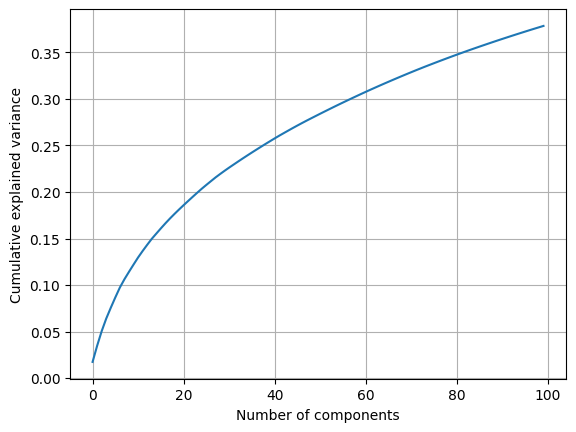

In [ ]:
# to understand variance
svd.fit(vectorized_words)

plt.plot(np.cumsum(svd.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.grid(True)

# note - variance isn't being explained

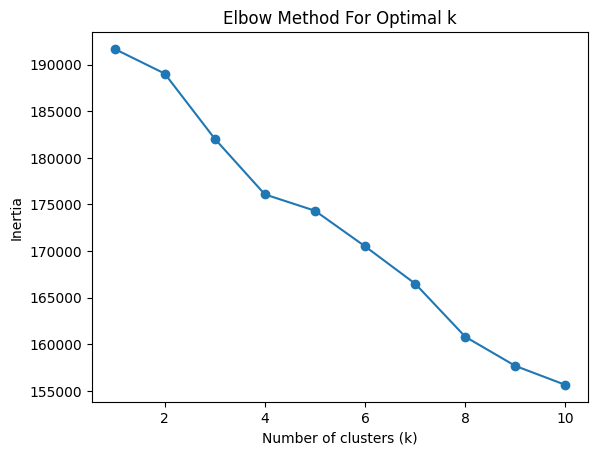

In [119]:
# Use Elbow Method to determine the number of clusters to use

inertias = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(reduced_data)  # use reduced TF-IDF data (from TruncatedSVD)
    inertias.append(kmeans.inertia_)

plt.plot(K, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

In [124]:
num_clusters=4
kmeans = KMeans(n_clusters=num_clusters, n_init=5, max_iter=500, random_state=42)
kmeans.fit(vectorized_words)

KMeans(max_iter=500, n_clusters=4, n_init=5, random_state=42)

C:\Users\Saaqib\AppData\Local\Temp\ipykernel_24624\727227039.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


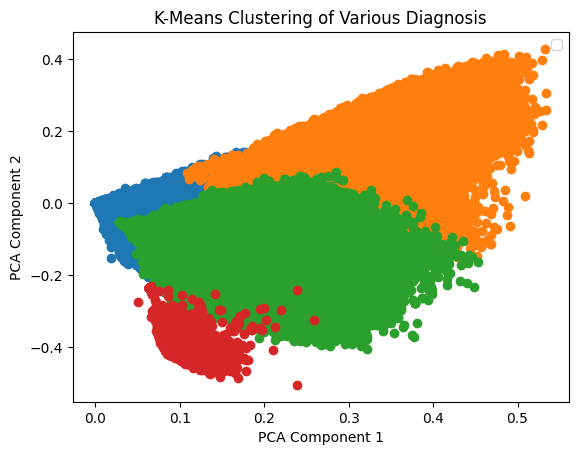

In [125]:
for i in range(num_clusters):
    plt.scatter(reduced_data[kmeans.labels_ == i, 0], 
                reduced_data[kmeans.labels_ == i, 1], 
                )

plt.legend()
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering of Various Diagnosis')
plt.show()

Clean and encode medication table first before joining onto main table


In [17]:
#df_medi[df_medi['hadm_id'].isin(df_admits['hadm_id'])]
df_medi.drop(columns = ['enter_provider_id','charttime','scheduletime','storetime','emar_id','emar_seq','poe_id','pharmacy_id','enter_provider_id'
                        ,'charttime','scheduletime','storetime'], inplace= True)
df_medi['medication'] = df_medi['medication'].fillna('No Medication')
df_medi.head(5)

,subject_id,hadm_id,medication,event_txt
0,10000032,22595853.0,Heparin,Administered
1,10000032,22595853.0,Raltegravir,Administered
2,10000032,22595853.0,Sodium Chloride 0.9% Flush,Flushed
3,10000032,22595853.0,Nicotine Patch,Not Applied
4,10000032,22595853.0,Furosemide,Not Given


In [47]:
# Define grouping rules for usage
administered = [
    'Administered', 'Partial Administered', 'Applied',
    'Confirmed', 'Started', 'Administered in Other Location',
    'Started in Other Location', 'Administered Bolus from IV Drip',
    'Applied in Other Location', 'Removed Existing / Applied New',
    'Removed Existing / Applied New in Other Location',
    'Restarted', 'Restarted in Other Location'
]

not_administered = [
    'Not Applied', 'Not Given', 'Not Flushed', 'Hold Dose', 'Removed',
    'Not Confirmed', 'Not Started', 'Not Assessed', 'Not Removed',
    'Not Stopped', 'Not Read', 'Not Given per Sliding Scale',
    'Not Stopped per Sliding Scale', 'Not Started per Sliding Scale',
    'Not Given per Sliding Scale in Other Location', 'Read', 'Read in Other Location', 'Stopped', 'Stopped As Directed',
    'Stopped - Unscheduled', 'Stopped - Unscheduled in Other Location',
    'Rate Change', 'Rate Change in Other Location','Removed in Other Location',
    'Confirmed in Other Location'

]

delayed = [s for s in df_medi['event_txt'].dropna().unique() if s.startswith('Delayed')]

other = [
    'Flushed', 'Flushed in Other Location', 'Assessed',
    'Assessed in Other Location', 'Infusion Reconciliation',
    'Infusion Reconciliation Not Done', 'Pain score re-assessment',
    'Pain score re-assess not done', 'Documented in O.R. Holding',
    'TPN Rate Not Changed', ' in Other Location', 'Partial ',
]

In [ ]:
def categorize_event(row):
    event = row['event_txt']
    med = row['medication']
    
    if pd.isna(event):
        return 'Other'
    elif event in administered and med != 'No Medication':
        return 'Administered'
    elif event in not_administered:
        return 'Not Administered'
    elif event in delayed:
        return 'Delayed'
    else:
        return 'Other'

# Apply the function row-wise
df_medi['usage'] = df_medi.apply(categorize_event, axis=1)

# Filter to only include 'Administered'
df_medi = df_medi[df_medi['usage'] == 'Administered']


C:\Users\smahmood\AppData\Local\Temp\ipykernel_2816\3524434096.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_medi['usage'] = df_medi.apply(categorize_event, axis=1)


In [53]:
df_medi['usage'].unique()

array([], dtype=object)

In [54]:
med_counts = df_medi.medication.value_counts()
pd.set_option('display.max_rows', 10000)
med_counts
#pd.reset_option('display.max_rows')


Series([], Name: count, dtype: int64)

In [46]:
df_medi[df_medi['medication']=='No Medication']

,subject_id,hadm_id,medication,event_txt,usage,medication_grouped
141,10000058,NaN,No Medication,Started,Administered,No Medication
203,10000117,27988844.0,No Medication,Started,Administered,No Medication
210,10000117,27988844.0,No Medication,Confirmed,Administered,No Medication
266,10000285,NaN,No Medication,Started,Administered,No Medication
271,10000492,NaN,No Medication,Started,Administered,No Medication
...,...,...,...,...,...,...
42808575,19999828,29734428.0,No Medication,Confirmed,Administered,No Medication
42808581,19999828,29734428.0,No Medication,Confirmed,Administered,No Medication
42808582,19999828,29734428.0,No Medication,Confirmed,Administered,No Medication
42808587,19999828,29734428.0,No Medication,Started,Administered,No Medication


In [38]:
301800/len(df_medi)

0.009317737248330788

In [2]:
from huggingface_hub import snapshot_download

#model_path = snapshot_download(repo_id="dmis-lab/biobert-base-cased-v1.1")
model_path = "C:\\Users\\smahmood\\.cache\\huggingface\\hub\\models--dmis-lab--biobert-base-cased-v1.1\\snapshots\\924f12e0c3db7f156a765ad53fb6b11e7afedbc8"

In [15]:
import os
os.environ["TRANSFORMERS_OFFLINE"] = "1"

In [3]:
# Load the tokenizer and model from the local directory
tokenizer = AutoTokenizer.from_pretrained(model_path, local_files_only=True)
model = AutoModel.from_pretrained(model_path, local_files_only=True)

In [4]:
save_directory = r"\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV"
tokenizer.save_pretrained(save_directory)
model.save_pretrained(save_directory)

In [ ]:
# Load from the local folder
#tokenizer = AutoTokenizer.from_pretrained(save_directory, local_files_only=True)
#model = AutoModel.from_pretrained(save_directory, local_files_only=True)

In [24]:
def get_cls_embedding(text, dims=50):
    with torch.no_grad():
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
        outputs = model(**inputs)
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # CLS token
    return cls_embedding.squeeze().numpy()  # 768-dim vector

In [26]:
df_medi['medication_grouped'] = df_medi.medication.apply(lambda x: str(x) if med_counts[x] > 1000 else ('Other Medication' if med_counts[x] < 1000 else 'No Medication'))

In [29]:
from torch.utils.data import DataLoader
import numpy as np

def get_embeddings_batch(text_list, batch_size=32):
    dataloader = DataLoader(text_list, batch_size=batch_size)
    embeddings = []

    with torch.no_grad():
        for batch in dataloader:
            inputs = tokenizer(batch, return_tensors="pt", truncation=True, padding=True)
            outputs = model(**inputs)
            cls_batch = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(cls_batch)

    return np.array(embeddings)

In [30]:
medications = df_medi['medication_grouped'].tolist()
embeddings = get_embeddings_batch(medications, batch_size=32)
df_medi['embedding'] = list(embeddings)

KeyboardInterrupt: 

In [27]:
df_medi.head()

,subject_id,hadm_id,medication,event_txt,usage,medication_grouped
0,10000032,22595853.0,Heparin,Administered,Administered,Heparin
1,10000032,22595853.0,Raltegravir,Administered,Administered,Raltegravir
7,10000032,22595853.0,Albuterol Inhaler,Administered,Administered,Albuterol Inhaler
8,10000032,22595853.0,Furosemide,Administered,Administered,Furosemide
9,10000032,22595853.0,Spironolactone,Administered,Administered,Spironolactone


In [23]:
df_medi.drop(columns= ['medication','event_txt','usage'])
df_medi_agg = df_medi.groupby(['hadm_id', 'subject_id']).agg({  
     'medication_grouped': lambda x: set(x),
     }).reset_index()

In [24]:
Y = mlb.fit_transform(df_medi_agg['medication_grouped'])

df_medi_encoded = pd.DataFrame.sparse.from_spmatrix(
    Y,
    index=df_medi_agg['hadm_id'],
    columns=mlb.classes_
)

In [25]:
df_medi_encoded = pd.merge(df_medi_agg,df_medi_encoded, on = 'hadm_id')

In [26]:
#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', None)
pd.reset_option('display.max_columns')
df_medi_encoded.head()

,hadm_id,subject_id,medication_grouped,ALPRAZolam,ARIPiprazole,Abacavir Sulfate,Acamprosate,AcetaZOLamide,Acetaminophen,Acetaminophen (Liquid),...,ibrutinib,imipenem-cilastatin,irbesartan,lurasidone,pilocarpine HCl,rOPINIRole,rifAXIMin,ruxolitinib,sevelamer CARBONATE,tiZANidine
0,20000024.0,16925328,"{FoLIC Acid, Gabapentin, Acetaminophen, OxyCOD...",0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,20000034.0,19430048,"{Sodium Bicarbonate, Senna, Ciprofloxacin HCl,...",0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,20000045.0,13413708,"{HYDROmorphone (Dilaudid), Acetaminophen IV, M...",0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,20000147.0,14990224,"{HYDROmorphone (Dilaudid), Chlorhexidine Gluco...",0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,20000180.0,15296741,"{HYDROmorphone (Dilaudid), Gabapentin, Lactulo...",0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
# Merge both encoded tables

df_full_dataset = pd.merge(
    df_admit_diagnosis_icd_encoded,
    df_medi_encoded,
    how='left',
    on='hadm_id'
)


In [28]:
#pd.set_option('display.max_columns', None)
df_full_dataset.head()

,hadm_id,subject_id_x,admission_type,admission_location,discharge_location,insurance,marital_status,race,anchor_age,gender,...,ibrutinib,imipenem-cilastatin,irbesartan,lurasidone,pilocarpine HCl,rOPINIRole,rifAXIMin,ruxolitinib,sevelamer CARBONATE,tiZANidine
0,20001596,15327072,4,10,13,3,1,7,65,1,...,0,0,0,0,0,0,0,0,0,0
1,20001633,18030855,5,2,6,0,2,28,28,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20001747,12270767,6,8,7,1,1,28,91,0,...,0,0,0,0,0,0,0,0,0,0
3,20001770,10117812,5,10,11,0,2,28,35,0,...,0,0,0,0,0,0,0,0,0,0
4,20001800,11828074,4,2,13,4,1,28,59,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Build Logistic Regression Model

In [29]:
df_full_dataset.drop(columns= ['medication_grouped','subject_id_y','icd_code_converted','icd_diagnosis_name','proc_name'],inplace=True)

In [ ]:
# correlation matrix
corr_matrix = df_full_dataset.corr()

plt.figure(figsize=(15, 15))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            xticklabels=corr_matrix.columns, yticklabels=corr_matrix.columns)
plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
corr_matrix = df_full_dataset.select_dtypes(include='number').corr().abs()

# Unstack and filter
high_corr = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # upper triangle, no self-pairs
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature 1', 'level_1': 'Feature 2', 0: 'Correlation'})
)

# Filter and sort
high_corr_filtered = high_corr[high_corr['Correlation'] > 0.5].sort_values(by='Correlation', ascending=False)

print(high_corr_filtered.head(50))